In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from pandas import DataFrame as DF
import itertools

import wandb
from models import HierarchicalModel
from utils import rate_code
from insilico_stimuli.stimuli import GaborSet

# mpl.style.use("seaborn")
# sns.set_context("paper")
# sns.set_style("darkgrid")
mpl.style.use("default")


/usr/lib/python3/dist-packages/requests/__init__.py:89: RequestsDependencyWarning: urllib3 (1.26.12) or chardet (3.0.4) doesn't match a supported version!
  warnings.warn("urllib3 ({}) or chardet ({}) doesn't match a supported "
/usr/local/lib/python3.8/dist-packages/pkg_resources/__init__.py:123: PkgResourcesDeprecationWarning: 0.23ubuntu1 is an invalid version and will not be supported in a future release
  warnings.warn(


In [2]:
gabor_locations = [(10, 0), (25, 0), (40, 0), (40, 0), (40, 25), (40, 40)]
orientations = [np.pi, np.pi/2]
phases = [np.pi]
spatial_frequencies = [1/20]
# spatial_frequencies = [1/20, 1/10, 1/5]
sizes = [25]
# sizes = [5, 10, 25]
gabor_params = {
    "canvas_size"         : [50, 50],
    "sizes"               : sizes,
    "spatial_frequencies" : spatial_frequencies,
    "contrasts"           : [1.0],
    "grey_levels"         : [0.0],
    "eccentricities"      : [0.0],
    "locations"           : gabor_locations,
    "orientations"        : orientations,  
    "phases"              : phases,
    "relative_sf"         : False
}

gabor_set = GaborSet(**gabor_params)
gabor_images = gabor_set.images()
# print all of the images


In [3]:
print(gabor_images.shape)

(12, 50, 50)


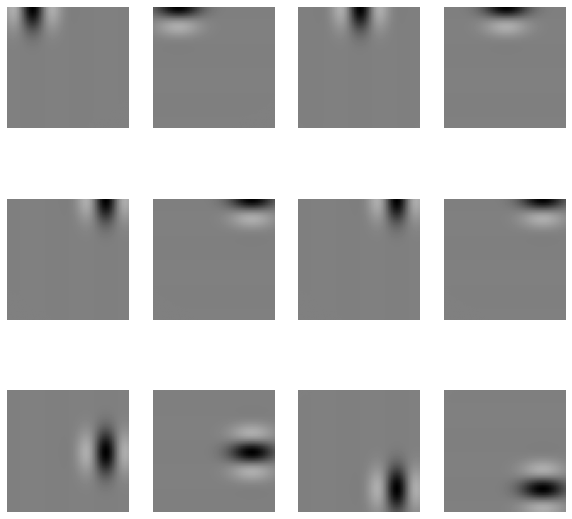

In [4]:
# plot 486 images
fig, axes = plt.subplots(3, 4, figsize=(10, 10))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(gabor_images[i], cmap="gray", vmin=-1, vmax=1)
    ax.axis("off")
plt.show()


In [16]:
gabors = np.load("/src/project/computed/gaabor_filters_overlapping_with_vertical_center.npy")
all_gabors = np.append(gabors, gabor_images, axis=0)

In [17]:
all_gabors.shape

(18, 50, 50)

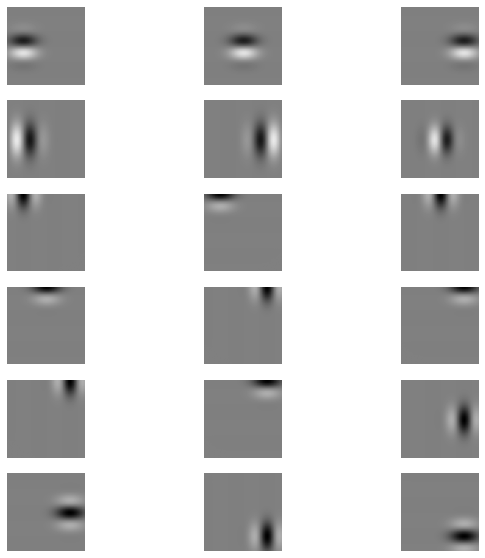

In [18]:
fig, axes = plt.subplots(6, 3, figsize=(10, 10))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(all_gabors[i], cmap="gray", vmin=-1, vmax=1)
    ax.axis("off")
plt.show()


In [ ]:
center_surround_params = {
    "canvas_size": gabor_params["canvas_size"],
    "spatial_frequencies_center": gabor_params["spatial_frequencies"],
    "spatial_frequencies_surround": [1/20],
    "phases_center":  [np.pi/2 + 2*np.pi*1/20*(25-10)],
    "phases_surround": [np.pi/2 + 2*np.pi*1/20*(25-10)],
    "grey_levels": gabor_params["grey_levels"],
    "orientations_center": [0.],
    "orientations_surround": [0.],
    "locations": [[25, 25]],
    "sizes_total": [50],
    "sizes_center": [30/4/50],
    "sizes_surround": [30/4/50],
    "contrasts_center": [1.0],
    "contrasts_surround": [1.0],
}

full_field_vertical_gabor_set = CenterSurround(**center_surround_params)
full_field_vertical_gabor = full_field_vertical_gabor_set.images()[0]

U, V = np.meshgrid(np.arange(50), np.arange(50))
XX = np.stack((U, V), axis=-1)
gauss_mask_right = np.exp(-np.sum((XX - np.array([40, 25]))**2, axis=-1) / (30/4)**2 / 2)
gauss_mask_left = np.exp(-np.sum((XX - np.array([10, 25]))**2, axis=-1) / (30/4)**2 / 2)

vertical_gabor_right = full_field_vertical_gabor * gauss_mask_right
vertical_gabor_left = full_field_vertical_gabor * gauss_mask_left

fig, axs = plt.subplots(nrows=1, ncols=3, dpi=200)
axs[0].imshow(vertical_gabor_left, cmap="gray", vmin=-1, vmax=1)
axs[0].axis("off")
axs[1].imshow(full_field_vertical_gabor, cmap="gray", vmin=-1, vmax=1)
axs[1].axis("off")
axs[2].imshow(vertical_gabor_right, cmap="gray", vmin=-1, vmax=1)
axs[2].axis("off")
plt.axis("off")
